In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Вкажи шлях до папки з твоїми даними
data_dir = 'data/raw/eye_disease'

In [2]:
classes = os.listdir(data_dir)
plt.figure(figsize=(12, 4))

for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    # Беремо першу картинку з папки
    img_name = os.listdir(cls_path)[0]
    img = cv2.imread(os.path.join(cls_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # Конвертуємо в RGB
    
    plt.subplot(1, len(classes), i+1)
    plt.imshow(img)
    plt.title(f"Клас: {cls}")
    plt.axis('off')
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'data/raw/eye_disease'

In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Ось правильний шлях: ".." означає "піднятися на рівень вище"
data_dir = '../data/raw/eye_disease'

# Перевірка: чи дійсно Python бачить цю папку
if os.path.exists(data_dir):
    print("Успіх! Папку знайдено за шляхом:", os.path.abspath(data_dir))
    classes = os.listdir(data_dir)
    print("Знайдені класи:", classes)
else:
    print(f"Помилка: Python не бачить папку. Перевір, чи існує шлях: {os.path.abspath(data_dir)}")

Успіх! Папку знайдено за шляхом: d:\university\нейронні мережі\lab\data\raw\eye_disease
Знайдені класи: ['full_df.csv', 'ODIR-5K', 'preprocessed_images']


In [4]:
import pandas as pd

# Рахуємо кількість файлів у кожній папці
class_counts = {cls: len(os.listdir(os.path.join(data_dir, cls))) for cls in classes}

# Будуємо графік
plt.figure(figsize=(6, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Розподіл класів (перевірка на дисбаланс)")
plt.ylabel("Кількість зображень")
plt.show()

NotADirectoryError: [WinError 267] The directory name is invalid: '../data/raw/eye_disease\\full_df.csv'

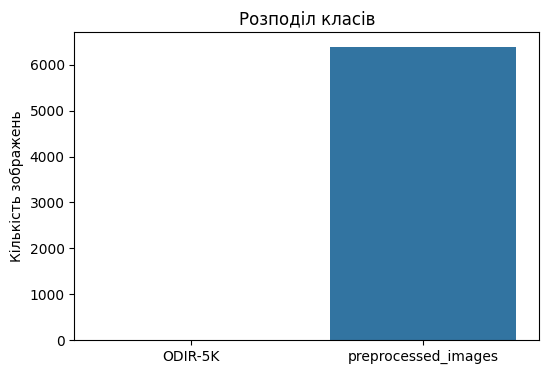

In [5]:
class_counts = {}

# Проходимося по всьому, що є в папці
for cls in classes:
    path = os.path.join(data_dir, cls)
    
    # Перевіряємо: чи це справді папка?
    if os.path.isdir(path):
        # Якщо так — рахуємо файли
        class_counts[cls] = len(os.listdir(path))

# Тепер будуємо графік
plt.figure(figsize=(6, 4))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Розподіл класів")
plt.ylabel("Кількість зображень")
plt.show()


In [6]:
plt.figure(figsize=(15, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    img_name = os.listdir(cls_path)[0] # Беремо перше фото
    img = cv2.imread(os.path.join(cls_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Клас: {cls}")
    plt.axis('off')
plt.show()

NotADirectoryError: [WinError 267] The directory name is invalid: '../data/raw/eye_disease\\full_df.csv'

<Figure size 1500x500 with 0 Axes>

In [7]:
# Заміни свій рядок `classes = os.listdir(data_dir)` на цей:
classes = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

# Далі йде твій цикл без змін
plt.figure(figsize=(15, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    
    # Отримуємо список файлів у папці
    files = os.listdir(cls_path)
    
    # Беремо перше фото (додаємо перевірку, щоб не взяти знову якийсь системний файл)
    img_name = files[0] 
    img = cv2.imread(os.path.join(cls_path, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Клас: {cls}")
    plt.axis('off')

plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


<Figure size 1500x500 with 0 Axes>

У папці ODIR-5K немає зображень!


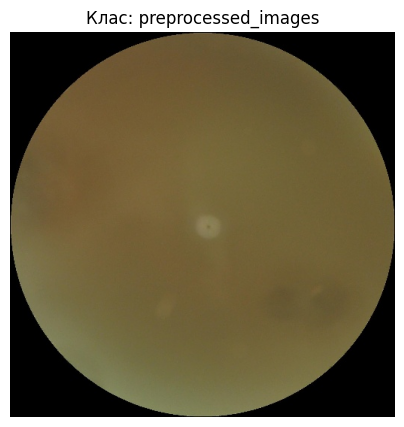

In [8]:
plt.figure(figsize=(15, 5))

for i, cls in enumerate(classes):
    cls_path = os.path.join(data_dir, cls)
    
    # Шукаємо всі файли, що закінчуються на .jpg, .png або .jpeg
    valid_extensions = ('.jpg', '.jpeg', '.png')
    files = [f for f in os.listdir(cls_path) if f.lower().endswith(valid_extensions)]
    
    if not files:
        print(f"У папці {cls} немає зображень!")
        continue
        
    # Беремо перший файл зі списку, який ми відфільтрували
    img_path = os.path.join(cls_path, files[0])
    img = cv2.imread(img_path)
    
    # Перевірка: чи відкрилась картинка?
    if img is None:
        print(f"Не вдалося відкрити файл: {files[0]}")
        continue
        
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f"Клас: {cls}")
    plt.axis('off')

plt.show()

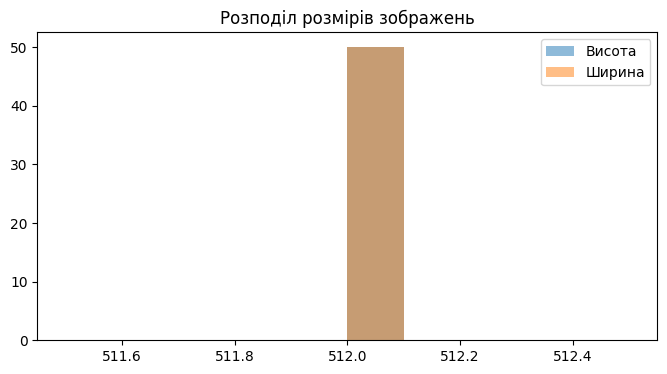

In [9]:
sizes = []
for cls in classes:
    for img_name in os.listdir(os.path.join(data_dir, cls))[:50]: # Беремо 50 фото для швидкості
        img = cv2.imread(os.path.join(data_dir, cls, img_name))
        if img is not None:
            sizes.append(img.shape[:2])

sizes = np.array(sizes)
plt.figure(figsize=(8, 4))
plt.hist(sizes[:,0], alpha=0.5, label='Висота')
plt.hist(sizes[:,1], alpha=0.5, label='Ширина')
plt.legend()
plt.title("Розподіл розмірів зображень")
plt.show()

In [10]:
def get_blur_score(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_scores = []
for cls in classes:
    path = os.path.join(data_dir, cls, os.listdir(os.path.join(data_dir, cls))[0])
    blur_scores.append(get_blur_score(path))

print(f"Середня чіткість прикладів: {dict(zip(classes, blur_scores))}")

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


In [11]:
def get_blur_score(path):
    img = cv2.imread(path)
    # Захист: якщо картинка не відкрилася, повертаємо 0
    if img is None:
        return 0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_scores = {}

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    
    # Знаходимо лише файли зображень
    valid_files = [f for f in os.listdir(cls_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if valid_files:
        # Беремо перше реальне зображення
        path = os.path.join(cls_path, valid_files[0])
        blur_scores[cls] = get_blur_score(path)
    else:
        blur_scores[cls] = "Немає зображень"

print(f"Показники чіткості для класів: {blur_scores}")

Показники чіткості для класів: {'ODIR-5K': 'Немає зображень', 'preprocessed_images': np.float64(258.6551839304011)}


In [12]:
import pandas as pd
import tensorflow as tf

# 1. Завантажуємо CSV (переконайся, що шлях правильний)
df = pd.read_csv('../data/raw/eye_disease/full_df.csv')

# 2. Перевіряємо, які там колонки (наприклад, 'filename' та 'label')
# Тобі потрібно знайти колонки, які відповідають за назву файлу та діагноз
# Наприклад:
df = df[['filename', 'label']] 

# 3. Створюємо датасет (це робиться в один крок!)
data_dir = '../data/raw/eye_disease/ODIR-5K/preprocessed_images'

train_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col='label',
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col='label',
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

KeyError: "['label'] not in index"

In [13]:
import pandas as pd

df = pd.read_csv('../data/raw/eye_disease/full_df.csv')

# Виведемо список усіх стовпчиків
print("Ось назви всіх стовпчиків у файлі:")
print(df.columns.tolist())

# Виведемо перші 5 рядків, щоб побачити дані
print("\nА ось як виглядають дані:")
print(df.head())


Ось назви всіх стовпчиків у файлі:
['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O', 'filepath', 'labels', 'target', 'filename']

А ось як виглядають дані:
   ID  Patient Age Patient Sex Left-Fundus Right-Fundus  \
0   0           69      Female  0_left.jpg  0_right.jpg   
1   1           57        Male  1_left.jpg  1_right.jpg   
2   2           42        Male  2_left.jpg  2_right.jpg   
3   4           53        Male  4_left.jpg  4_right.jpg   
4   5           50      Female  5_left.jpg  5_right.jpg   

                            Left-Diagnostic Keywords  \
0                                           cataract   
1                                      normal fundus   
2  laser spot，moderate non proliferative retinopathy   
3                        macular epiretinal membrane   
4             moderate non proliferative retinopathy   

                Right-Diagnostic Keyw

In [14]:
import tensorflow as tf
import pandas as pd

# 1. Завантажуємо файл
df = pd.read_csv('../data/raw/eye_disease/full_df.csv')

# 2. Шлях до картинок
data_dir = '../data/raw/eye_disease/ODIR-5K/preprocessed_images'

# 3. Визначаємо список стовпчиків, які є нашими класами
target_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

# 4. Створюємо датасети
# Ми використовуємо label_mode='categorical', щоб Keras зрозумів, що це багатокласова класифікація
train_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col=target_cols,
    label_mode='categorical', 
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col=target_cols,
    label_mode='categorical',
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

AttributeError: module 'keras.utils' has no attribute 'image_dataset_from_dataframe'

In [15]:
train_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col=target_cols,
    label_mode='categorical', # Це правильно для твоїх 8 колонок
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)


AttributeError: module 'keras.utils' has no attribute 'image_dataset_from_dataframe'

In [16]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [17]:
import tensorflow as tf
import pandas as pd

# 1. Завантажуємо файл
df = pd.read_csv('../data/raw/eye_disease/full_df.csv')

# 2. Шлях до картинок
data_dir = '../data/raw/eye_disease/ODIR-5K/preprocessed_images'

# 3. Визначаємо список стовпчиків, які є нашими класами
target_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

# 4. Створюємо датасети
# Ми використовуємо label_mode='categorical', щоб Keras зрозумів, що це багатокласова класифікація
train_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col=target_cols,
    label_mode='categorical', 
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_ds = tf.keras.utils.image_dataset_from_dataframe(
    df,
    directory=data_dir,
    x_col='filename',
    y_col=target_cols,
    label_mode='categorical',
    image_size=(180, 180),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

AttributeError: module 'keras.utils' has no attribute 'image_dataset_from_dataframe'

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
import random

# Налаштування стилю графіків
sns.set_theme(style="whitegrid")
data_dir = '../data/raw/eye_disease/ODIR-5K/preprocessed_images'
df = pd.read_csv('../data/raw/eye_disease/full_df.csv')

C:\Users\admin\AppData\Local\Temp\ipykernel_28988\3004322969.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Patient Sex', data=df, ax=axes[1], palette='pastel')


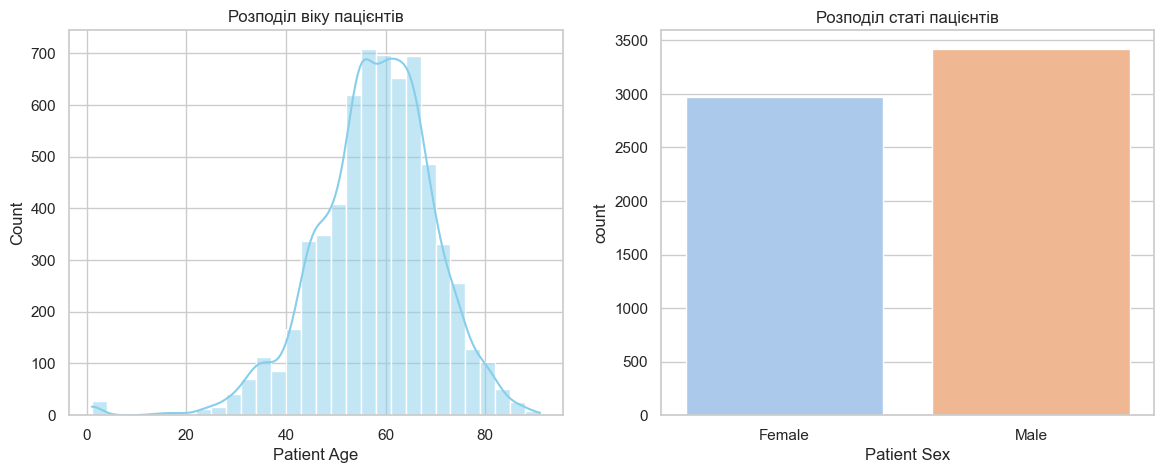

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гістограма віку
sns.histplot(df['Patient Age'], bins=30, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Розподіл віку пацієнтів')

# Графік статі
sns.countplot(x='Patient Sex', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Розподіл статі пацієнтів')

plt.show()

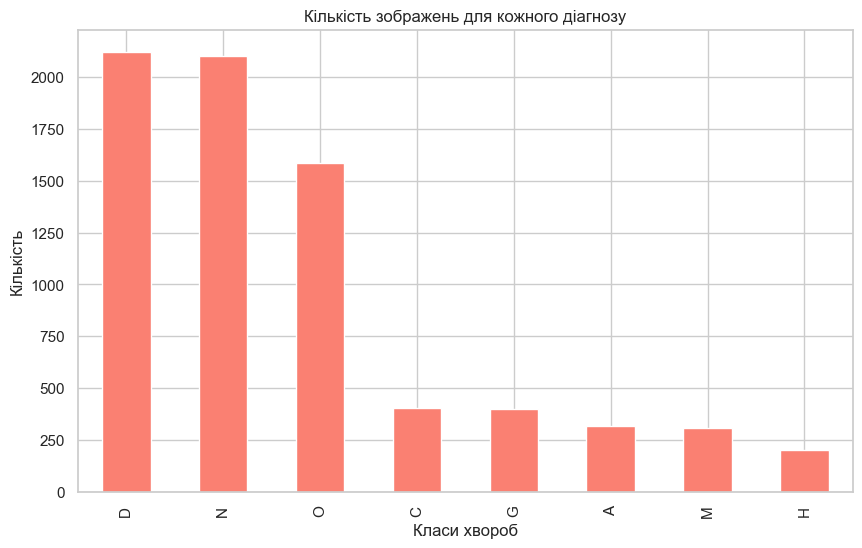

In [20]:
target_cols = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
class_counts = df[target_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
class_counts.plot(kind='bar', color='salmon')
plt.title('Кількість зображень для кожного діагнозу')
plt.xlabel('Класи хвороб')
plt.ylabel('Кількість')
plt.show()

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'


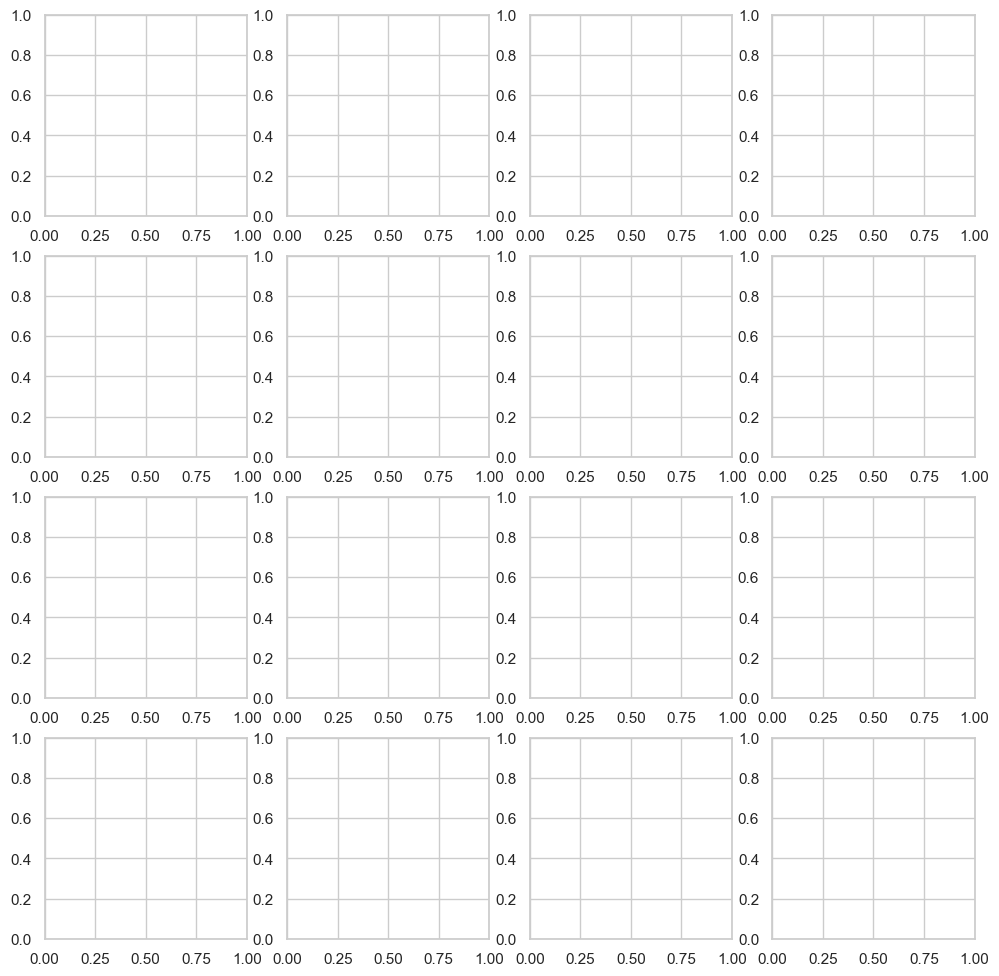

In [21]:
def show_random_images(df, data_dir, n=4):
    fig, axes = plt.subplots(n, n, figsize=(12, 12))
    sample_files = df['filename'].sample(n*n).values
    
    for i, ax in enumerate(axes.flat):
        img_path = os.path.join(data_dir, sample_files[i])
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

show_random_images(df, data_dir)

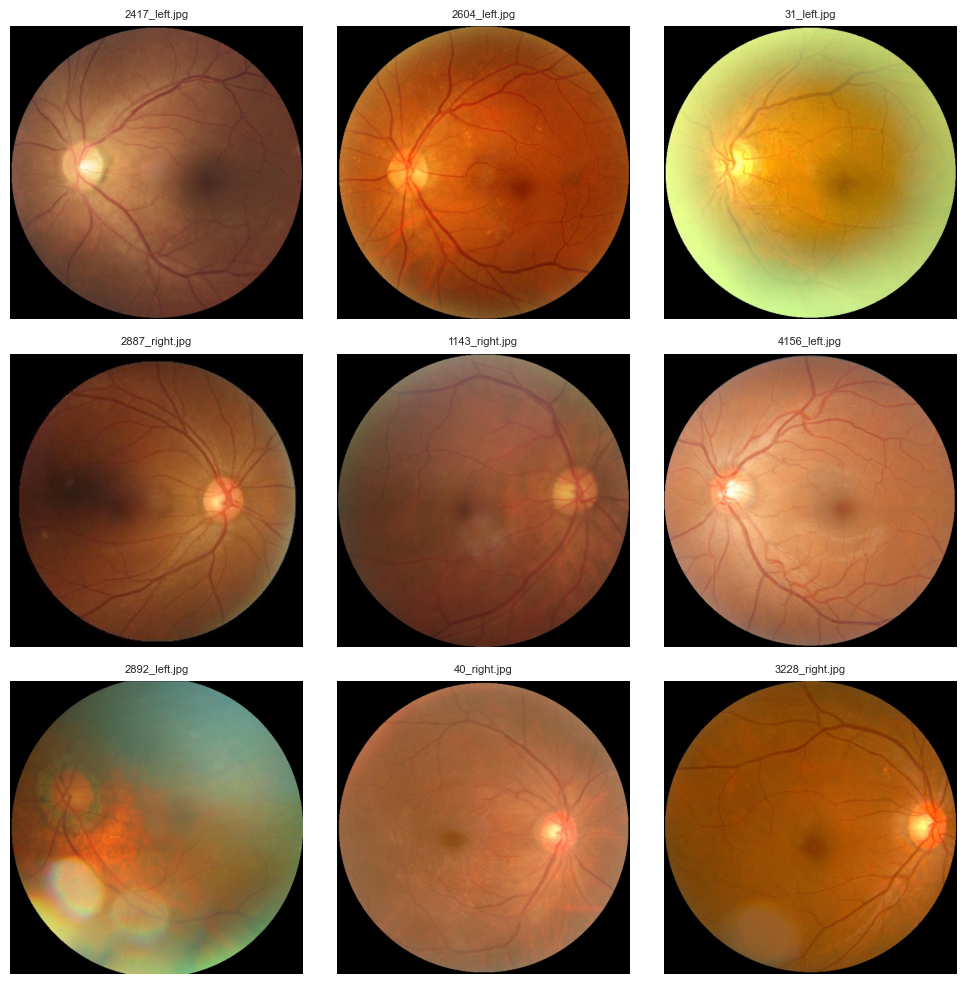

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt

data_dir = '../data/raw/eye_disease/preprocessed_images'

def show_random_images(df, data_dir, n=3):
    fig, axes = plt.subplots(n, n, figsize=(10, 10))
    sample_files = df['filename'].sample(n*n).values
    
    for i, ax in enumerate(axes.flat):
        img_path = os.path.join(data_dir, sample_files[i])
        
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.set_title(sample_files[i], fontsize=8)
        else:
            ax.text(0.5, 0.5, 'Файл не знайдено', ha='center')
            print(f"Помилка: не знайдено {img_path}")
            
        ax.axis('off')
    plt.tight_layout()
    plt.show()

show_random_images(df, data_dir)

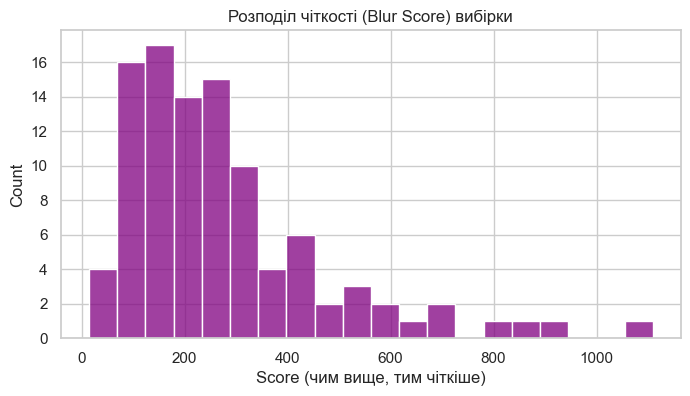

In [ ]:
def get_blur_score(path):
    img = cv2.imread(path)
    if img is None: return 0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

sample_files = df['filename'].sample(100).values
scores = [get_blur_score(os.path.join(data_dir, f)) for f in sample_files]

plt.figure(figsize=(8, 4))
sns.histplot(scores, bins=20, color='purple')
plt.title('Розподіл чіткості (Blur Score) вибірки')
plt.xlabel('Score (чим вище, тим чіткіше)')
plt.show()